In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

images = []
label = []

base_image_path = os.path.join(path, "PlantVillage")

if os.path.exists(base_image_path):
    folders = os.listdir(base_image_path)

    for folder in folders:
        folder_path = os.path.join(base_image_path, folder)
        if os.path.isdir(folder_path):
            items = os.listdir(folder_path)

            for item in items:
                file = os.path.join(folder_path, item)
                images.append(file)
                label.append(folder)
        else:
            print(f"Skipping non-directory item: {folder_path}")
else:
    print(f"Error: Base image path does not exist: {base_image_path}")

print(f"Found {len(images)} images and {len(label)} labels.")

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease
Found 20639 images and 20639 labels.


In [3]:
data = pd.DataFrame({"file_paths" : images, "labels" : label})

In [4]:
data

,file_paths,labels
0,/kaggle/input/plantdisease/PlantVillage/Pepper...,Pepper__bell___Bacterial_spot
1,/kaggle/input/plantdisease/PlantVillage/Pepper...,Pepper__bell___Bacterial_spot
2,/kaggle/input/plantdisease/PlantVillage/Pepper...,Pepper__bell___Bacterial_spot
3,/kaggle/input/plantdisease/PlantVillage/Pepper...,Pepper__bell___Bacterial_spot
4,/kaggle/input/plantdisease/PlantVillage/Pepper...,Pepper__bell___Bacterial_spot
...,...,...
20634,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato__Tomato_mosaic_virus
20635,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato__Tomato_mosaic_virus
20636,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato__Tomato_mosaic_virus
20637,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato__Tomato_mosaic_virus


In [5]:
data.isnull().sum()

,0
file_paths,0
labels,0


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data['labels'].unique()

array(['Pepper__bell___Bacterial_spot', 'Potato___healthy',
       'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus',
       'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot',
       'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite',
       'Tomato_Early_blight', 'Tomato__Target_Spot',
       'Pepper__bell___healthy', 'Potato___Late_blight',
       'Tomato_Late_blight', 'Potato___Early_blight',
       'Tomato__Tomato_mosaic_virus'], dtype=object)

In [8]:
data.shape

(20639, 2)

In [9]:
data = data.sample(frac=1).reset_index(drop=True)

In [10]:
data

,file_paths,labels
0,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato_Leaf_Mold
1,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato__Target_Spot
2,/kaggle/input/plantdisease/PlantVillage/Pepper...,Pepper__bell___healthy
3,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato_Spider_mites_Two_spotted_spider_mite
4,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato__Tomato_YellowLeaf__Curl_Virus
...,...,...
20634,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato__Target_Spot
20635,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato_healthy
20636,/kaggle/input/plantdisease/PlantVillage/Pepper...,Pepper__bell___Bacterial_spot
20637,/kaggle/input/plantdisease/PlantVillage/Tomato...,Tomato_Leaf_Mold


In [11]:
import matplotlib.pyplot as plt
import seaborn as sb

In [12]:
value_counts = data['labels'].value_counts()
value_counts

,count
labels,
Tomato__Tomato_YellowLeaf__Curl_Virus,3209
Tomato_Bacterial_spot,2127
Tomato_Late_blight,1909
Tomato_Septoria_leaf_spot,1771
Tomato_Spider_mites_Two_spotted_spider_mite,1676
Tomato_healthy,1591
Pepper__bell___healthy,1478
Tomato__Target_Spot,1404
Tomato_Early_blight,1000


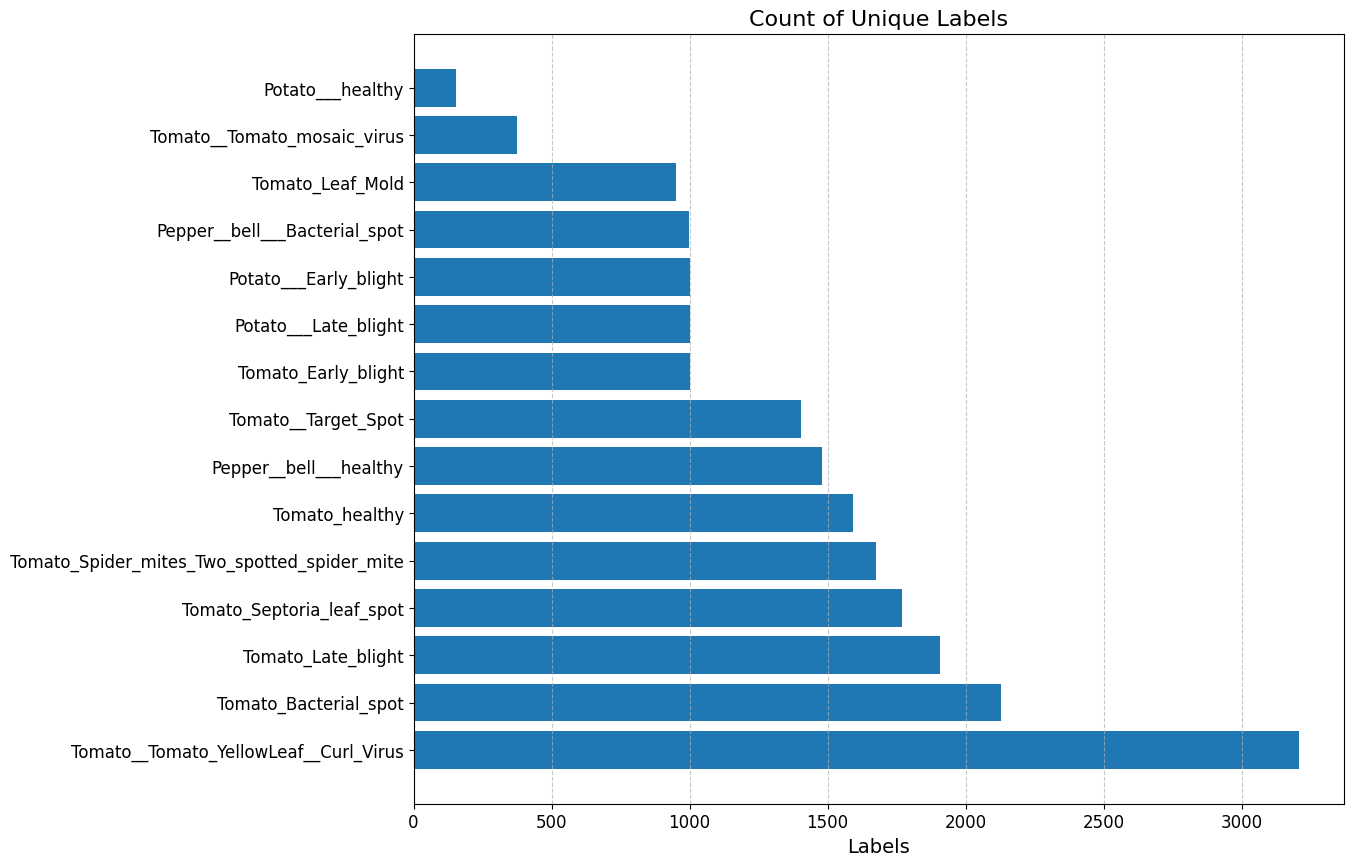

In [13]:
plt.figure(figsize=(12,10))
plt.barh(value_counts.index, value_counts.values)
plt.xlabel('Labels', fontsize=14)

# plt.ylabel('Number of images', fontsize=14)

plt.title('Count of Unique Labels', fontsize=16)
plt.tick_params(axis='both', labelsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

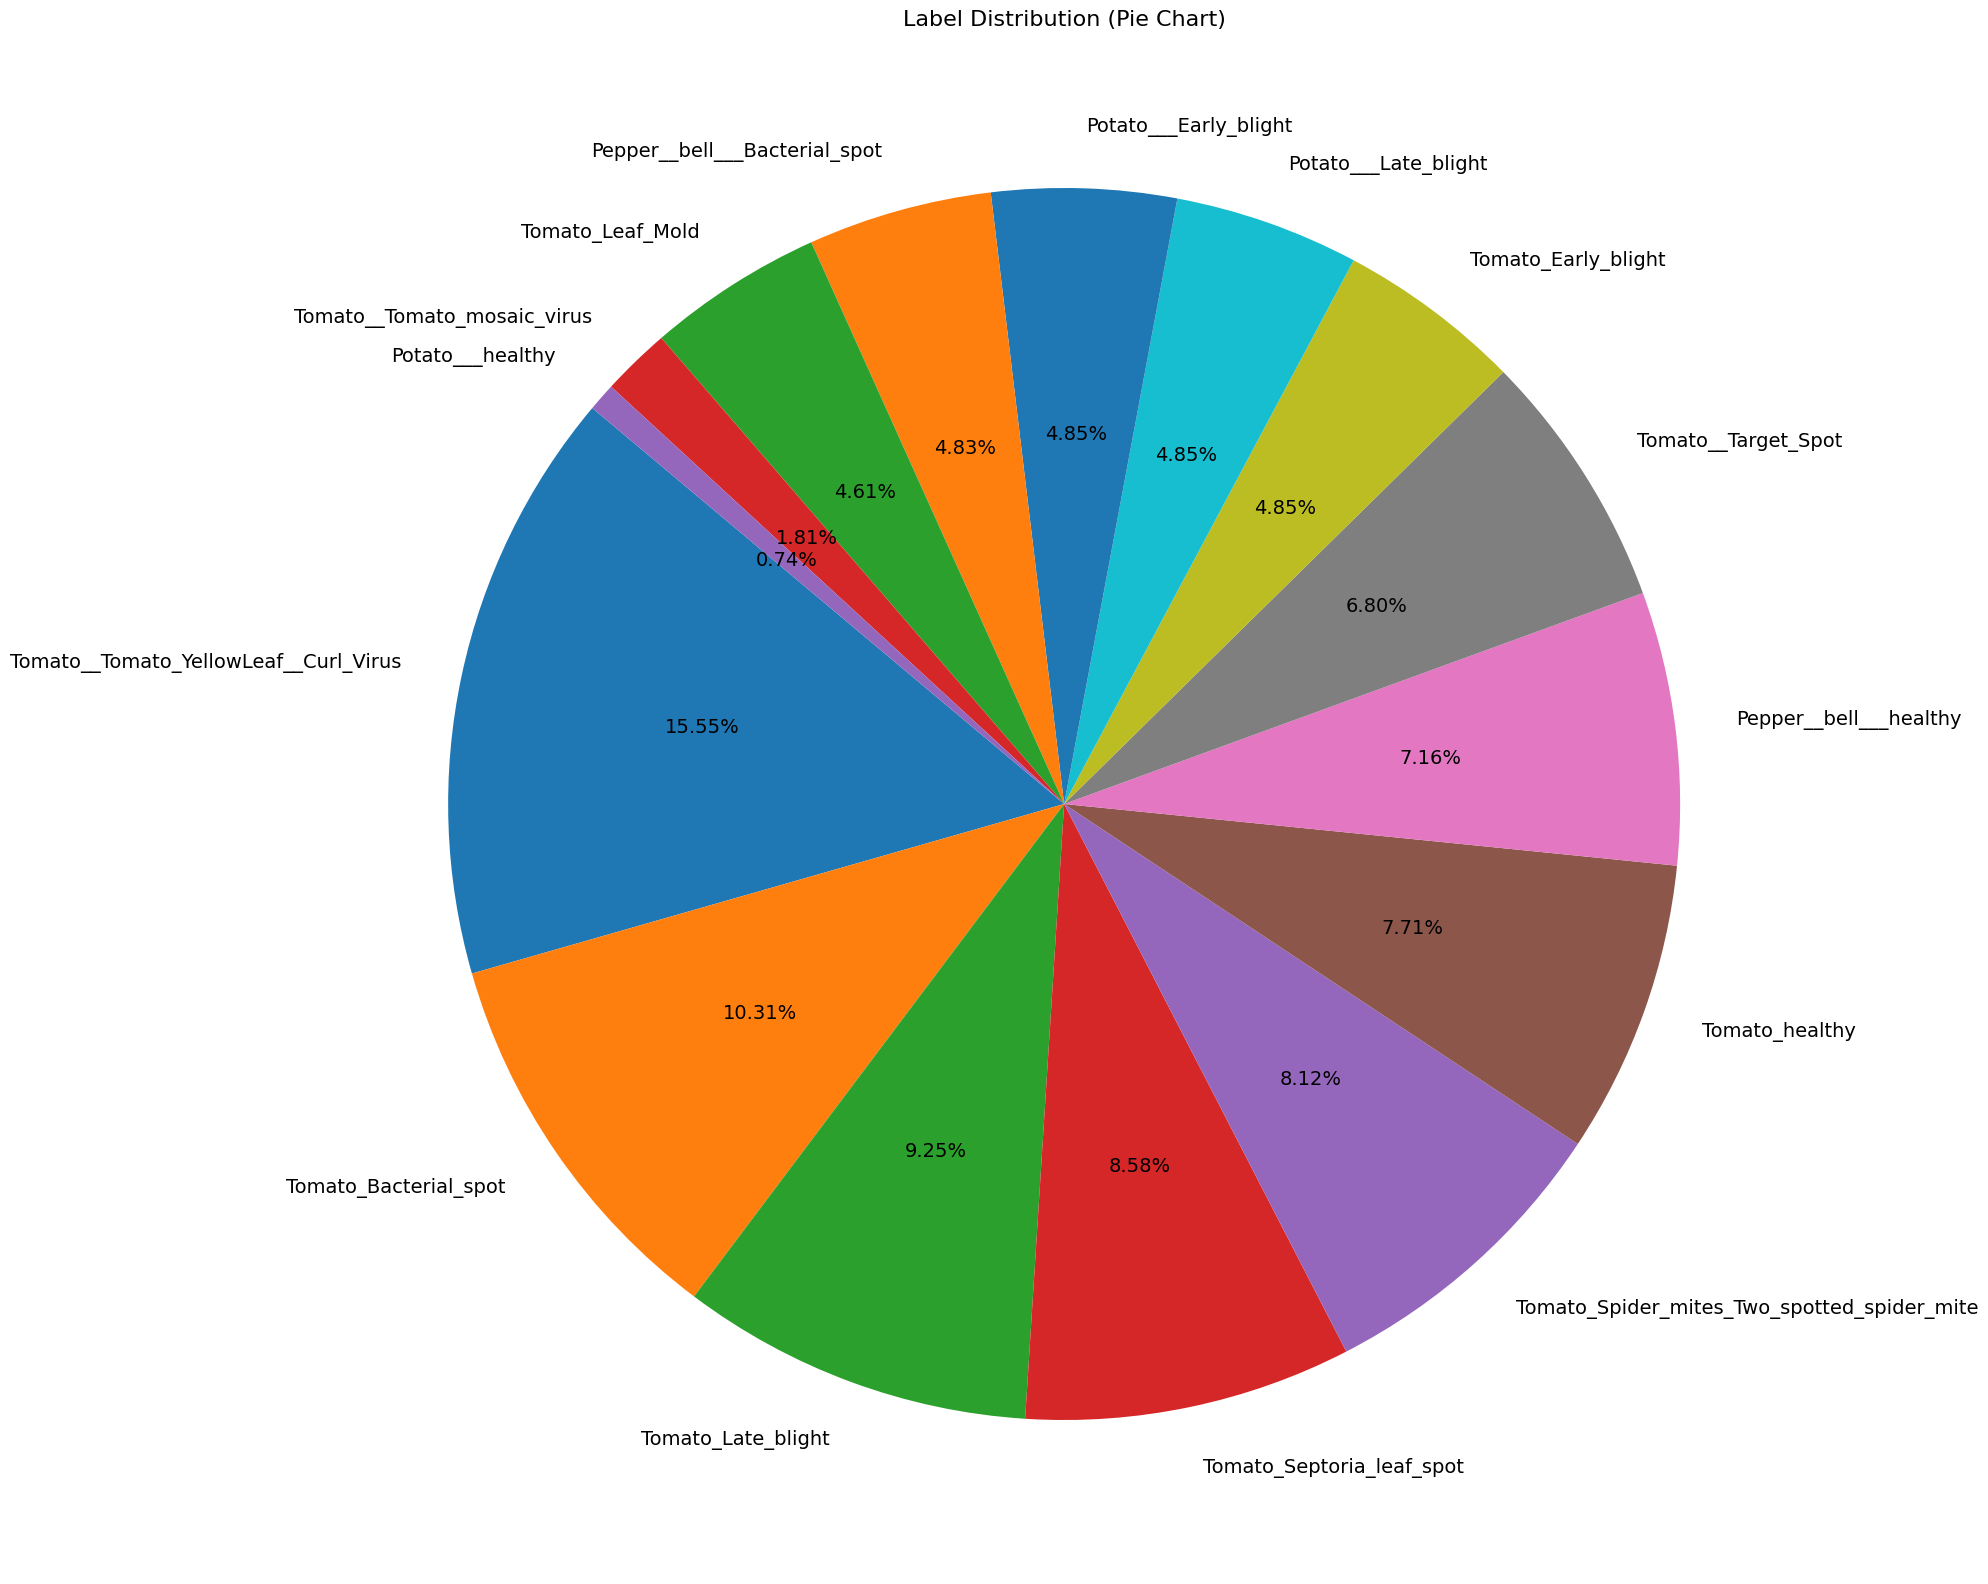

In [14]:
plt.figure(figsize=(20,20))
plt.pie(
    value_counts.values,
    labels=value_counts.index,
    autopct='%1.2f%%',
    startangle=140,          # Rotate for better layout
    textprops={'fontsize': 14}
)

plt.title('Label Distribution (Pie Chart)', fontsize=16)

# plt.axis('equal')

plt.show()

In [15]:
import cv2

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis('off')
    plt.title('Image Preview')
    plt.show()

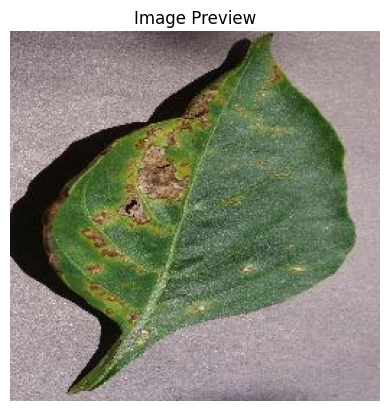

In [16]:
path1 = "/kaggle/input/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG"
load_image(path1)

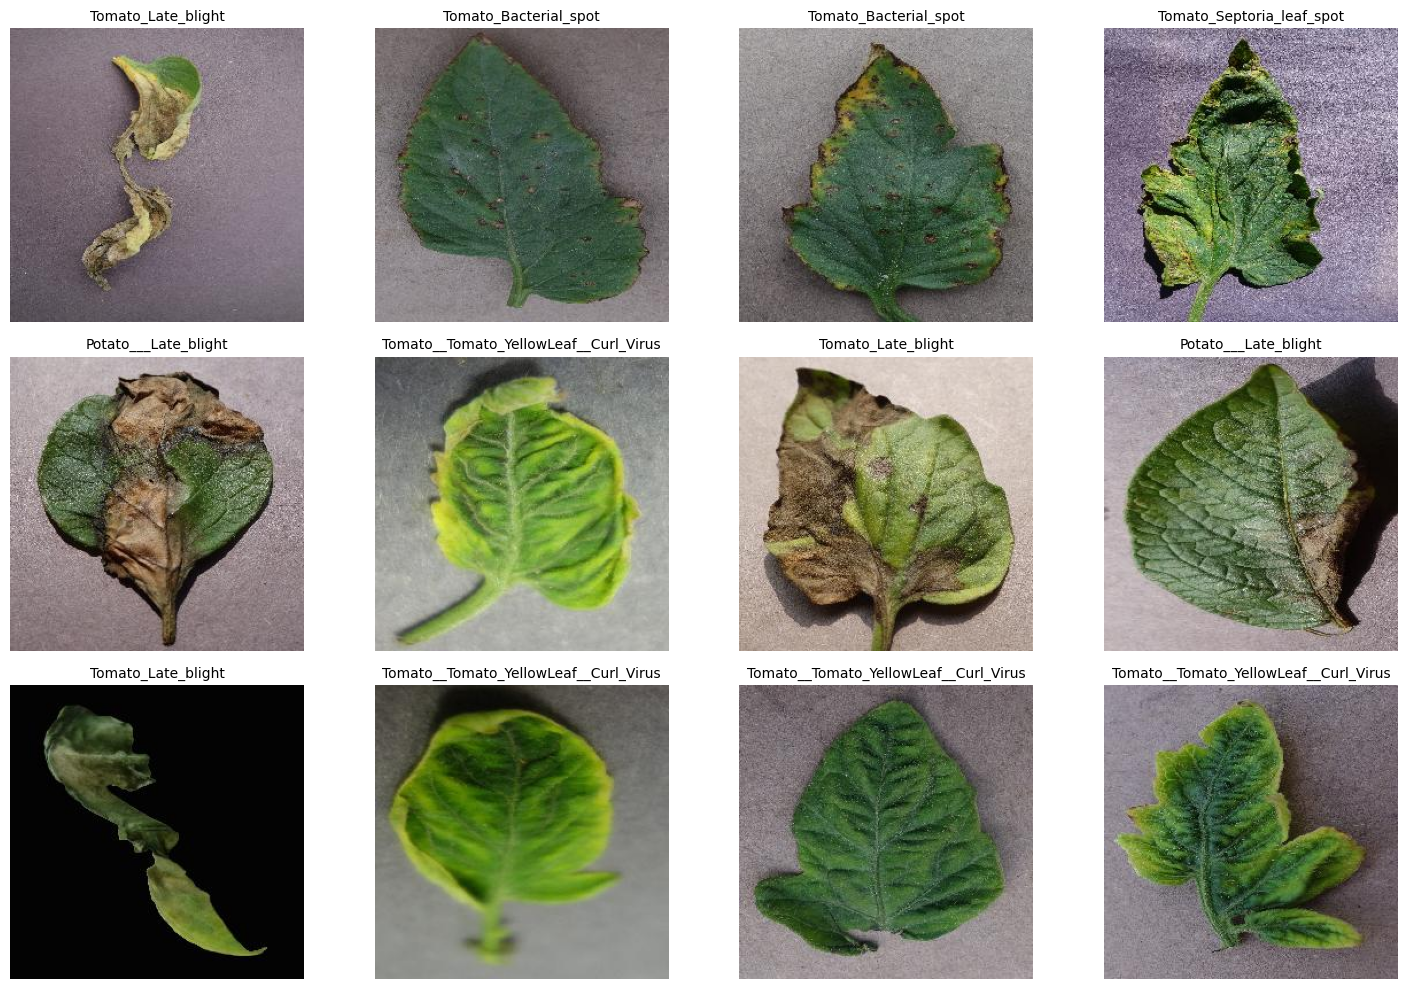

In [17]:
import random

random_rows = data.sample(n=12).reset_index(drop=True)

rows, cols = 3, 4
plt.figure(figsize=(15, 10))

for i in range(len(random_rows)):

    path = random_rows.loc[i, 'file_paths']
    label = random_rows.loc[i, 'labels']

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(label, fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

train_paths, test_paths, train_labels, test_labels = train_test_split(
    data['file_paths'],
    data['labels'],
    test_size=0.25,
    stratify=data['labels'],
    random_state=42
)

In [19]:
print(train_paths.size)
print(test_paths.size)


15479
5160


In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')


In [21]:
train_df = pd.DataFrame({
    'filename': train_paths,
    'class': train_labels
})

test_df = pd.DataFrame({
    'filename': test_paths,
    'class': test_labels
})

In [22]:

test_datagen = ImageDataGenerator(rescale=1./255)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)


In [23]:
train_agumentation = train_datagen.flow_from_dataframe(
    train_df,
    x_col = 'filename',
    y_col = 'class',
    target_size = (256, 256),
    color_mode = 'rgb',
    class_mode = 'categorical',
    batch_size = 32,
    shuffle = True
)

Found 15478 validated image filenames belonging to 15 classes.


In [24]:
test_agumentation = test_datagen.flow_from_dataframe(
    test_df,
    x_col = 'filename',
    y_col = 'class',
    target_size = (256, 256),
    color_mode = 'rgb',
    class_mode = 'categorical',
    batch_size = 32,
    shuffle = False
)

Found 5160 validated image filenames belonging to 15 classes.


In [25]:
from tensorflow.keras.layers import Dense , Dropout , BatchNormalization , Flatten,Conv2D , MaxPool2D , Input
from tensorflow.keras.models import Sequential

In [26]:

model = Sequential([
    Input(shape = (256 , 256 , 3)),
    Conv2D(32 , (3,3) , strides = (1,1) , padding = "same" , activation = "relu"),
    MaxPool2D(pool_size = (2,2) , strides = (2,2)),
    Conv2D(64 , (3,3) , strides = (1,1) , padding = "same" , activation = "relu"),
    MaxPool2D(pool_size = (2,2) , strides = (2,2)),
    Conv2D(128 , (3,3) , strides = (1,1) , padding = "same" , activation = "relu"),
    MaxPool2D(pool_size = (2,2) , strides = (2,2)),
    MaxPool2D(pool_size = (2,2) , strides = (2,2)),
    Flatten(),
    Dense(128 , activation = "relu"),
    Dropout(0.2),
    Dense(64 , activation = "relu"),
    BatchNormalization(),
    Dense(15 , activation = "softmax")
])

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,297,167 (16.39 MB)

 Trainable params: 4,297,039 (16.39 MB)

 Non-trainable params: 128 (512.00 B)

In [28]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = "val_accuracy" ,
    patience = 4 ,
    restore_best_weights = True)


In [30]:
model.fit(
    train_agumentation,
    epochs = 20,
    batch_size = 32 ,
    validation_data = test_agumentation,
    callbacks = [early_stopping]
)

Epoch 1/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 416s 840ms/step - accuracy: 0.4256 - loss: 1.8162 - val_accuracy: 0.5990 - val_loss: 1.2547
Epoch 2/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 294s 607ms/step - accuracy: 0.6581 - loss: 1.0415 - val_accuracy: 0.7140 - val_loss: 0.7968
Epoch 3/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 295s 609ms/step - accuracy: 0.7346 - loss: 0.8003 - val_accuracy: 0.7723 - val_loss: 0.6542
Epoch 4/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 299s 618ms/step - accuracy: 0.7894 - loss: 0.6350 - val_accuracy: 0.8587 - val_loss: 0.4318
Epoch 5/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 300s 620ms/step - accuracy: 0.8254 - loss: 0.5257 - val_accuracy: 0.8242 - val_loss: 0.5329
Epoch 6/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 296s 612ms/step - accuracy: 0.8414 - loss: 0.4842 - val_accuracy: 0.8725 - val_loss: 0.3861
Epoch 7/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 295s 610ms/step - accuracy: 0.8606 - loss: 0.4307 - val_accuracy: 0.9252 - val_loss: 0.2434
Epoch 8/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 292s 603ms/step - accuracy: 0.8771 -

In [31]:
test_loss , test_accuracy = model.evaluate(test_agumentation)
print(test_loss)
print("-------------")
print(test_accuracy)

162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9455 - loss: 0.1674
0.16740211844444275
-------------
0.9455426335334778


In [32]:
predictions = model.predict(test_agumentation)


162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step


In [33]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [34]:
predicted_labels = np.argmax(predictions, axis=1)
print(f"Classification Report:\n{classification_report(test_agumentation.classes, predicted_labels)}")

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       249
           1       0.97      0.98      0.98       370
           2       0.96      0.99      0.98       250
           3       0.95      0.92      0.93       250
           4       1.00      0.84      0.91        38
           5       0.92      0.99      0.95       532
           6       0.90      0.86      0.88       250
           7       0.92      0.95      0.93       477
           8       0.98      0.96      0.97       238
           9       0.98      0.91      0.94       443
          10       0.93      0.90      0.92       419
          11       0.93      0.79      0.86       351
          12       0.99      0.99      0.99       802
          13       0.99      0.95      0.97        93
          14       0.88      1.00      0.94       398

    accuracy                           0.95      5160
   macro avg       0.95      0.93      0.94      5160
wei

In [35]:
predicted_labels = np.argmax(predictions, axis=1)
print(f"Confusion Matrix:\n{confusion_matrix(test_agumentation.classes, predicted_labels)}")

Confusion Matrix:
[[243   1   0   0   0   1   0   1   0   3   0   0   0   0   0]
 [  6 362   0   0   0   0   0   1   1   0   0   0   0   0   0]
 [  0   0 247   0   0   0   0   3   0   0   0   0   0   0   0]
 [  0   0   1 230   0   1   3  14   0   1   0   0   0   0   0]
 [  0   2   0   3  32   0   0   0   0   0   1   0   0   0   0]
 [  0   0   0   0   0 528   0   0   0   0   0   0   4   0   0]
 [  0   0   2   0   0  15 214  16   0   1   1   1   0   0   0]
 [  1   3   2   5   0   2  10 452   0   0   0   0   1   0   1]
 [  0   0   0   0   0   3   1   1 229   2   1   0   1   0   0]
 [  4   4   4   0   0  13   8   2   3 404   1   0   0   0   0]
 [  0   0   0   1   0   0   0   0   0   0 379  20   2   1  16]
 [  0   0   0   4   0   6   1   2   0   3  19 279   0   0  37]
 [  0   0   0   0   0   5   0   0   0   0   2   0 795   0   0]
 [  0   0   0   0   0   0   1   0   0   0   3   1   0  88   0]
 [  0   0   0   0   0   0   0   1   0   0   0   0   0   0 397]]


In [36]:
predicted_labels = np.argmax(predictions, axis=1)
print(f"Accuracy: {accuracy_score(test_agumentation.classes, predicted_labels)}")

Accuracy: 0.9455426356589147


In [37]:
model.save('CNN_model.keras')